In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pylab import exp
from qutip import coherent, destroy, qeye, tensor

In [3]:
# Hilbert space dimension for each mode
N = 30

# Signal amplitude
alpha = 0.7

# Beam splitter transmissivity
T = 0.95

# Beam splitter angle
theta = np.arccos(np.sqrt(T))

# Photon numbers
n_values = np.arange(N)

# Signal states
signal_plus = coherent(N, alpha)
signal_minus = coherent(N, -alpha)

In [4]:
# Local oscillator amplitude
beta = -np.sqrt(T / (1 - T)) * alpha

# Local oscillator coherent state
LO = coherent(N, beta)

In [6]:
# Single-mode annihilation operator
from matplotlib.pylab import exp


a_single = destroy(N)

# Identity
I = qeye(N)

# Signal mode annihilation operator
a = tensor(a_single, I)

# Local oscillator mode annihilation operator
b = tensor(I, a_single)

# Beam splitter unitary
U_BS = (theta * (a.dag() * b-a * b.dag())).expm()

# Input state: |+α> ⊗ |β>
psi_plus_in = tensor(signal_plus, LO)

# Input state: |-α> ⊗ |β>
psi_minus_in = tensor(signal_minus, LO)

# Output states
psi_plus_out = U_BS * psi_plus_in
psi_minus_out = U_BS * psi_minus_in

# Reduced density matrix of the detector mode
rho_plus_detector = psi_plus_out.ptrace(0)

rho_minus_detector = psi_minus_out.ptrace(0)

# Calculating P(n)

In [7]:
P_plus = np.real(np.diag(rho_plus_detector.full()))

P_minus = np.real(np.diag(rho_minus_detector.full()))

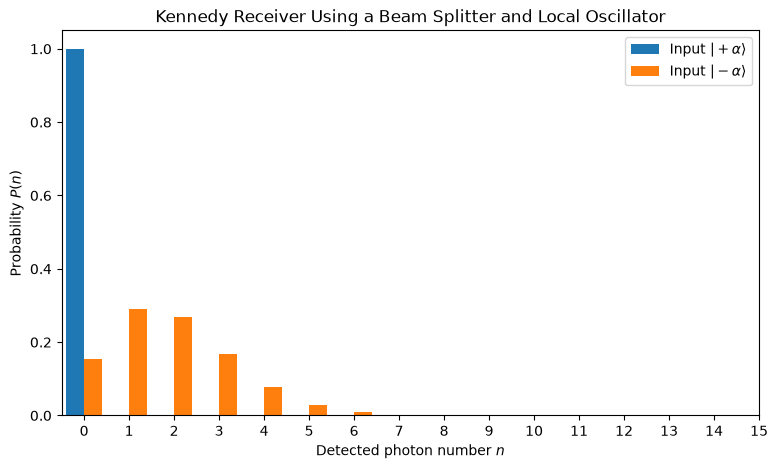

In [8]:
plt.figure(figsize=(9, 5))

# Distribution when |+α> was sent
plt.bar(n_values - 0.2, P_plus, width=0.4, label=r"Input $|+\alpha\rangle$")

# Distribution when |-α> was sent
plt.bar(n_values + 0.2, P_minus, width=0.4, label=r"Input $|-\alpha\rangle$")

plt.xlabel(r"Detected photon number $n$")
plt.ylabel(r"Probability $P(n)$")
plt.title("Kennedy Receiver Using a Beam Splitter and Local Oscillator")

plt.xticks(n_values)
plt.xlim(-0.5, 15)
plt.legend()
plt.show()